# CodeAlpha Data Analytics Internship — Task 2

## Exploratory Data Analysis: Student Academic Performance

### Objective

The objective of this project is to explore student academic data, identify patterns and relationships between study habits and final grades, investigate potential anomalies, and examine data-quality issues.

### Research Questions

1. Is study time associated with final mathematics grades?
2. How are absences related to final grades?
3. How do previous academic failures relate to final grades?
4. Which numerical variables show the strongest association with final grades?
5. Are there missing values, duplicate records or unusual observations?

### Dataset

The project uses the Student Performance dataset from the UCI Machine Learning Repository. The analysis initially focuses on mathematics performance.

### Tools and Libraries

Python, Pandas, NumPy, Matplotlib and Seaborn.

### Methodology

1. Load and inspect the dataset.
2. Examine variables, data types and data quality.
3. Calculate descriptive statistics.
4. Explore distributions, patterns and relationships.
5. Investigate hypotheses using statistics and visualizations.
6. Summarize findings, limitations and conclusions.


In [14]:
# Install the UCI dataset package
%pip install -q ucimlrepo

# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo

# Fetch the Student Performance dataset
student_performance = fetch_ucirepo(id=320)

# Combine features and mathematics grades into one DataFrame
df = pd.concat(
    [
        student_performance.data.features,
        student_performance.data.targets
    ],
    axis=1
)

# Keep the mathematics dataset only if the package returns both subjects
print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)
print("\nFirst five records:")
display(df.head())

Dataset loaded successfully!
Dataset shape: (649, 33)

First five records:


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


In [15]:
# 1. Dataset dimensions
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

# 2. Column names
print("\nColumn names:")
print(df.columns.tolist())

# 3. Data types and non-null counts
print("\nDataset information:")
df.info()

# 4. Descriptive statistics
print("\nNumerical summary:")
display(df.describe().T)

# 5. Categorical variable summary
categorical_cols = df.select_dtypes(
    include=["object", "category", "bool"]
).columns

print("\nCategorical columns:")
print(list(categorical_cols))

if len(categorical_cols) > 0:
    display(df[categorical_cols].describe().T)

Number of rows: 649
Number of columns: 33

Column names:
['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      649 non-null    object
 1   sex         649 non-null    object
 2   age         649 non-null    int64 
 3   address     649 non-null    object
 4   famsize     649 non-null    object
 5   Pstatus     649 non-null    object
 6   Medu        649 non-null    int64 
 7   Fedu        649 non-null    int64 
 8   Mjob        649 non-null    object
 9   Fjob        649 non-null    object
 10  rea

,count,mean,std,min,25%,50%,75%,max
age,649.0,16.744222,1.218138,15.0,16.0,17.0,18.0,22.0
Medu,649.0,2.514638,1.134552,0.0,2.0,2.0,4.0,4.0
Fedu,649.0,2.306626,1.099931,0.0,1.0,2.0,3.0,4.0
traveltime,649.0,1.568567,0.748660,1.0,1.0,1.0,2.0,4.0
studytime,649.0,1.930663,0.829510,1.0,1.0,2.0,2.0,4.0
failures,649.0,0.221880,0.593235,0.0,0.0,0.0,0.0,3.0
famrel,649.0,3.930663,0.955717,1.0,4.0,4.0,5.0,5.0
freetime,649.0,3.180277,1.051093,1.0,3.0,3.0,4.0,5.0
goout,649.0,3.184900,1.175766,1.0,2.0,3.0,4.0,5.0
Dalc,649.0,1.502311,0.924834,1.0,1.0,1.0,2.0,5.0



Categorical columns:
['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']


,count,unique,top,freq
school,649,2,GP,423
sex,649,2,F,383
address,649,2,U,452
famsize,649,2,GT3,457
Pstatus,649,2,T,569
Mjob,649,5,other,258
Fjob,649,5,other,367
reason,649,4,course,285
guardian,649,3,mother,455
schoolsup,649,2,no,581


In [16]:
print("Missing values per column:")
display(df.isnull().sum().to_frame("Missing Values"))

print("Total missing values:", df.isnull().sum().sum())

print("\nDuplicate rows:", df.duplicated().sum())

grade_cols = [col for col in ["G1","G2","G3"] if col in df.columns]

if grade_cols:
    print("\nGrade ranges:")
    display(df[grade_cols].agg(["min","max","mean"]).T)

    for col in grade_cols:
      unusual = df[~df[col].between(0,20)]
      print(f"{col}:{len(unusual)} values outside the 0-20 range")

important_cols = [
    col for col in ["studytime", "absences", "failures","G3"]
    if col in df.columns
]

print("\nMissinf calues in key variables:")
display(df[important_cols].isnull().sum())

Missing values per column:


,Missing Values
school,0
sex,0
age,0
address,0
famsize,0
Pstatus,0
Medu,0
Fedu,0
Mjob,0
Fjob,0


Total missing values: 0

Duplicate rows: 0

Grade ranges:


,min,max,mean
G1,0.0,19.0,11.399076
G2,0.0,19.0,11.570108
G3,0.0,19.0,11.906009


G1:0 values outside the 0-20 range
G2:0 values outside the 0-20 range
G3:0 values outside the 0-20 range

Missinf calues in key variables:


,0
studytime,0
absences,0
failures,0
G3,0


## Research Questions and Hypotheses

Before analyzing the data, the following questions were selected:

1. **Study time:** Is greater weekly study time associated with higher final mathematics grades?

   * Hypothesis: Study time and final grades are positively associated.

2. **Absences:** Are higher absence counts associated with lower final grades?

   * Hypothesis: Absences and final grades are negatively associated.

3. **Previous failures:** Do students with more previous failures have different average final grades?

   * Hypothesis: Average final grades differ across previous-failure groups.

4. **Data quality:** Are there missing values, duplicate records or unusual observations that could affect interpretation?

These hypotheses will be investigated using descriptive statistics, visualizations and appropriate statistical tests. They will not be assumed to be true before examining the results.


Final grades grouped by weekly study time:


,count,mean,median
studytime,,,
1,212,10.84,11.0
2,305,12.09,12.0
3,97,13.23,13.0
4,35,13.06,13.0


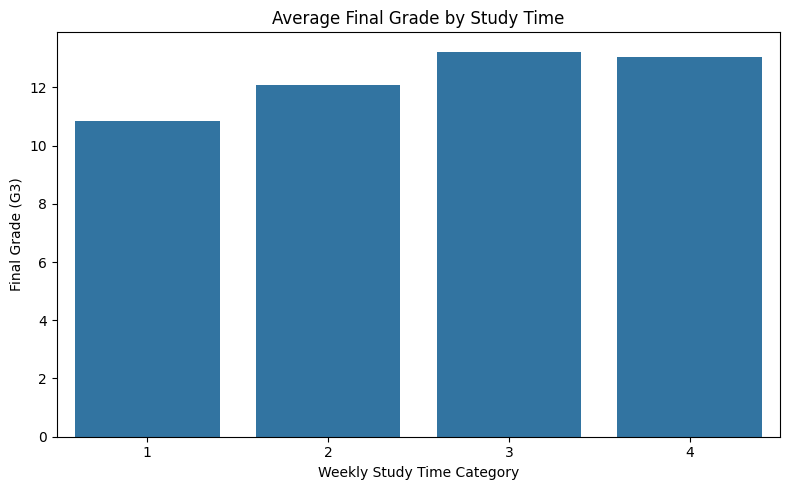

In [17]:
# Average final grade by study time
study_summary = (
    df.groupby("studytime", dropna=False)["G3"]
    .agg(["count", "mean", "median"])
    .round(2)
)

print("Final grades grouped by weekly study time:")
display(study_summary)

# Visualize the relationship
plt.figure(figsize=(8, 5))

sns.barplot(data=df, x="studytime", y="G3", errorbar=None)

plt.title("Average Final Grade by Study Time")
plt.xlabel("Weekly Study Time Category")
plt.ylabel("Final Grade (G3)")
plt.tight_layout()
plt.show()

Absence statistics:


,Absences
count,649.000000
mean,3.659476
std,4.640759
min,0.000000
25%,0.000000
50%,2.000000
75%,6.000000
max,32.000000


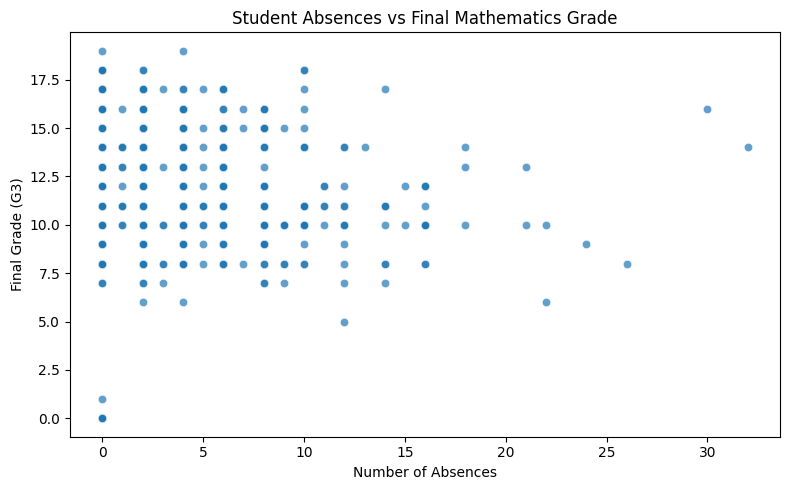

In [20]:
# Summary statistics for absences
print("Absence statistics:")
display(df["absences"].describe().to_frame("Absences"))

# Scatter plot of absences and final grade
plt.figure(figsize=(8, 5))

sns.scatterplot(data=df, x="absences", y="G3", alpha=0.7)

plt.title("Student Absences vs Final Mathematics Grade")
plt.xlabel("Number of Absences")
plt.ylabel("Final Grade (G3)")
plt.tight_layout()
plt.show()

Final grades by number of previous failures:


,count,mean,median
failures,,,
0,549,12.51,12.0
1,70,8.64,10.0
2,16,8.81,9.5
3,14,8.07,8.5


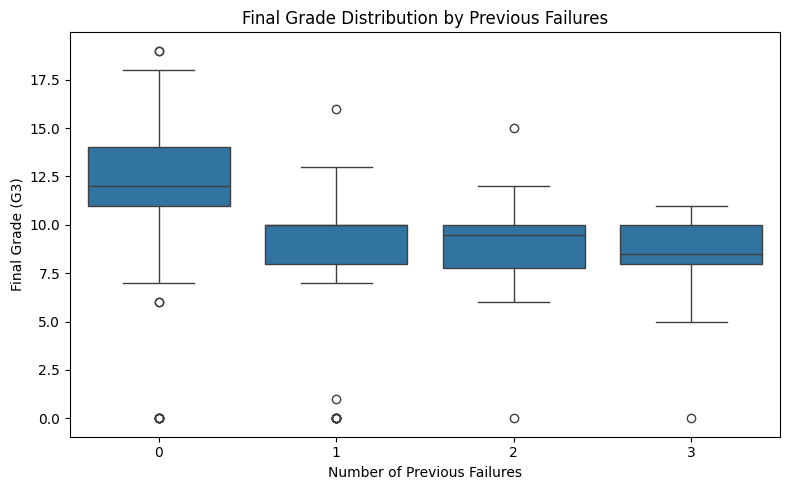

In [21]:
# Compare final grades across previous-failure categories
failure_summary = (
    df.groupby("failures", dropna=False)["G3"]
    .agg(["count", "mean", "median"])
    .round(2)
)

print("Final grades by number of previous failures:")
display(failure_summary)

# Visualize the distributions
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="failures", y="G3")

plt.title("Final Grade Distribution by Previous Failures")
plt.xlabel("Number of Previous Failures")
plt.ylabel("Final Grade (G3)")
plt.tight_layout()
plt.show()

In [22]:
from scipy.stats import spearmanr

# Keep only rows with valid values for each pair
def test_spearman(data, x_col, y_col):
    pair = data[[x_col, y_col]].dropna()

    if len(pair) < 3 or pair[x_col].nunique() < 2 or pair[y_col].nunique() < 2:
        print(f"Not enough variation or data to test {x_col} and {y_col}.")
        return

    result = spearmanr(pair[x_col], pair[y_col])

    print(f"\nVariables: {x_col} and {y_col}")
    print("Number of observations:", len(pair))
    print("Spearman correlation:", round(result.statistic, 3))
    print("P-value:", round(result.pvalue, 5))

    if result.pvalue < 0.05:
        print("Result: Evidence of a statistically significant association.")
    else:
        print("Result: Insufficient evidence of a statistically significant association.")

test_spearman(df, "studytime", "G3")
test_spearman(df, "absences", "G3")


Variables: studytime and G3
Number of observations: 649
Spearman correlation: 0.275
P-value: 0.0
Result: Evidence of a statistically significant association.

Variables: absences and G3
Number of observations: 649
Spearman correlation: -0.159
P-value: 5e-05
Result: Evidence of a statistically significant association.


Correlation with final grade (G3):


,Correlation with G3
G3,1.000000
G2,0.918548
G1,0.826387
studytime,0.249789
Medu,0.240151
Fedu,0.211800
famrel,0.063361
goout,-0.087641
absences,-0.091379
health,-0.098851


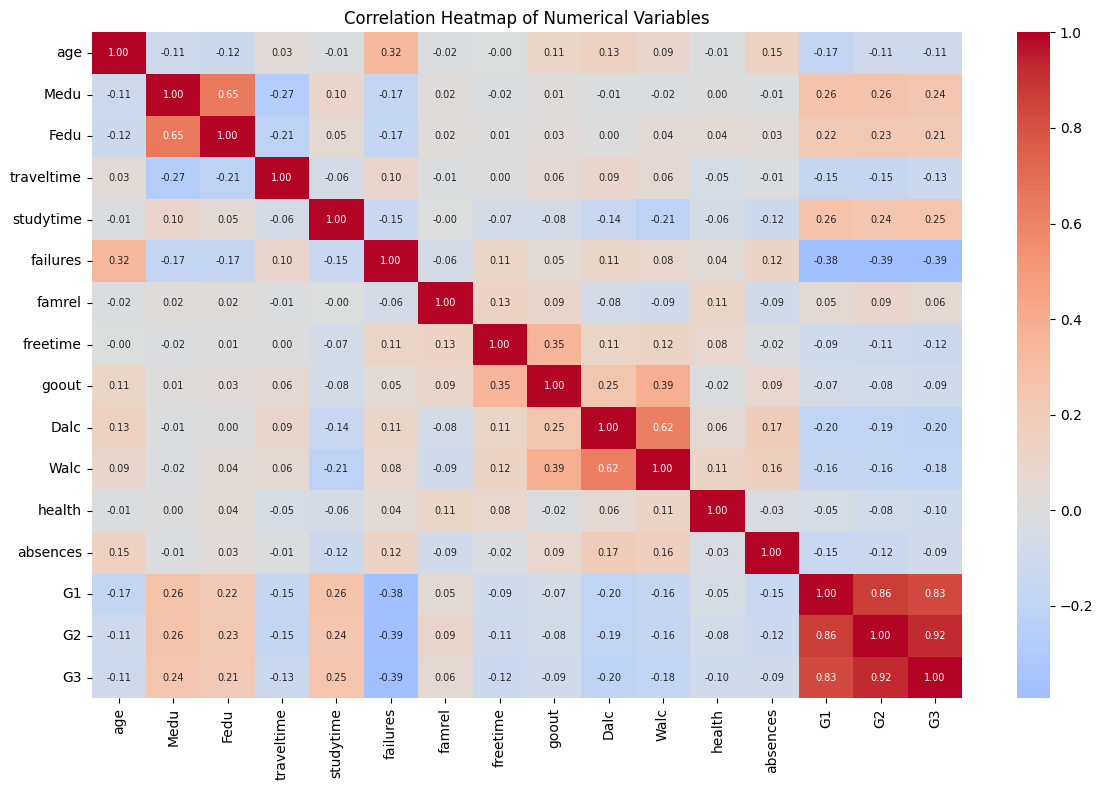

In [23]:
# Select numerical columns
numeric_df = df.select_dtypes(include="number")

# Calculate correlations
correlation_matrix = numeric_df.corr()

# Display correlations with final grade
print("Correlation with final grade (G3):")

if "G3" in correlation_matrix.columns:
    display(
        correlation_matrix["G3"]
        .sort_values(ascending=False)
        .to_frame("Correlation with G3")
    )

# Plot correlation heatmap
plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 7}
)

plt.title("Correlation Heatmap of Numerical Variables")
plt.tight_layout()
plt.show()

In [24]:
# Calculate the IQR for absences
q1 = df["absences"].quantile(0.25)
q3 = df["absences"].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers = df[
    (df["absences"] < lower_bound) |
    (df["absences"] > upper_bound)
]

print("First quartile:", q1)
print("Third quartile:", q3)
print("IQR:", iqr)
print("Lower outlier boundary:", lower_bound)
print("Upper outlier boundary:", upper_bound)
print("Potential absence outliers:", len(outliers))

display(outliers[["absences", "G3"]].head(10))

First quartile: 0.0
Third quartile: 6.0
IQR: 6.0
Lower outlier boundary: -9.0
Upper outlier boundary: 15.0
Potential absence outliers: 21


,absences,G3
40,16,10
103,16,10
150,24,9
155,22,6
161,16,8
197,32,14
206,16,12
211,16,12
212,30,16
217,21,13


In [25]:
print("=" * 55)
print("STUDENT PERFORMANCE: EDA FINDINGS")
print("=" * 55)

print("\n1. Dataset overview")
print(f"Records: {df.shape[0]}")
print(f"Variables: {df.shape[1]}")

print("\n2. Data quality")
print(f"Total missing values: {df.isnull().sum().sum()}")
print(f"Duplicate rows: {df.duplicated().sum()}")

print("\n3. Final grade")
print(f"Mean grade: {df['G3'].mean():.2f}")
print(f"Median grade: {df['G3'].median():.2f}")
print(f"Minimum grade: {df['G3'].min()}")
print(f"Maximum grade: {df['G3'].max()}")

print("\n4. Average grade by study time")
display(
    df.groupby("studytime")["G3"]
    .mean()
    .round(2)
    .to_frame("Average Final Grade")
)

print("\n5. Average grade by previous failures")
display(
    df.groupby("failures")["G3"]
    .mean()
    .round(2)
    .to_frame("Average Final Grade")
)

print("\n6. Potential absence outliers:", len(outliers))
print("\nUse the charts and statistical tests above to interpret these results.")

STUDENT PERFORMANCE: EDA FINDINGS

1. Dataset overview
Records: 649
Variables: 33

2. Data quality
Total missing values: 0
Duplicate rows: 0

3. Final grade
Mean grade: 11.91
Median grade: 12.00
Minimum grade: 0
Maximum grade: 19

4. Average grade by study time


,Average Final Grade
studytime,
1,10.84
2,12.09
3,13.23
4,13.06



5. Average grade by previous failures


,Average Final Grade
failures,
0,12.51
1,8.64
2,8.81
3,8.07



6. Potential absence outliers: 21

Use the charts and statistical tests above to interpret these results.


In [26]:
from pathlib import Path

# Create a folder for the project outputs
output_dir = Path("eda_outputs")
output_dir.mkdir(exist_ok=True)

# Save the dataset
df.to_csv(output_dir / "student_performance_data.csv", index=False)

# Save the correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 7}
)
plt.title("Correlation Heatmap of Numerical Variables")
plt.tight_layout()
plt.savefig(output_dir / "correlation_heatmap.png", dpi=150)
plt.close()

print("Dataset and correlation heatmap saved in:", output_dir)
print("Files:", [p.name for p in output_dir.iterdir()])

Dataset and correlation heatmap saved in: eda_outputs
Files: ['student_performance_data.csv', 'correlation_heatmap.png']


In [27]:
import shutil
from google.colab import files

shutil.make_archive("CodeAlpha_StudentPerformanceEDA", "zip", output_dir)
files.download("CodeAlpha_StudentPerformanceEDA.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Findings and Conclusion

### 1. Dataset Overview

The dataset was inspected to understand its dimensions, variables, data types and descriptive statistics.

### 2. Data Quality

Missing values, duplicate records, grade ranges and potential outliers were examined. Any identified issues were considered before interpreting the results.

### 3. Study Time and Final Grades

The average final grades across study-time categories were compared using descriptive statistics and visualization. The observed pattern should be described using the calculated averages.

### 4. Absences and Final Grades

A scatter plot and Spearman correlation were used to investigate the association between absences and final grades. The correlation coefficient and p-value should be reported with an appropriate interpretation.

### 5. Previous Failures

Grade distributions and average final grades were compared across previous-failure categories. Differences should be described according to the observed results.

### 6. Numerical Relationships

A correlation matrix and heatmap were used to examine relationships among numerical variables. Correlations indicate associations and should not be interpreted as proof of causation.

### 7. Limitations

This analysis focuses on the mathematics dataset and the variables available in it. The findings describe the observed dataset and do not establish that any single factor causes academic outcomes.

### Conclusion

The analysis uses descriptive statistics, visualizations and correlation tests to explore student academic performance. The final conclusions should summarize the patterns supported by the actual outputs and identify any data-quality limitations.

